# 01 — Análise Exploratória de Dados (EDA)

**Objetivo:**  EstatísticaExplorar as distribuições, validar a premissa de clusterização (Hopkins = 0.70) e fundamentar decisões via testes: Shapiro-Wilk (não-normalidade), Spearman (features independentes) e Mann-Whitney (gênero não diferencia grupos → excluído do KMeans).

**Inputs:** `data/raw/dataset.csv`

**Outputs:** `reports/figures/*.png`

---

**Roteiro:**

1. Setup, tema e configurações locais e globais
2. Carregamendo dos dados
3. Inspeção inicial: tipos, nulos, duplicatas e cardinalidade
4. Estatística descritiva + distribuições univariadas
5. Hopkins statistic + Shapiro-Wilk
6. Correlação (Spearman + Pearson) + heatmap
7. Levene (variância) + Mann-Whitney U (diferença por gênero)
8. Scatter renda × score_gasto
9. Fechamento: Resumo dos achados

### Etapa 1 — Setup, tema e configurações locais e globais

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scipy.stats import (
    levene, mannwhitneyu, pearsonr,
    shapiro, spearmanr, ttest_ind,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from src.config import CONFIG, CAMINHOS
from src.data import padronizar_colunas
from src.viz_config import PALETTE, CORES

DADOS_BRUTOS = CAMINHOS.dados_raw / CAMINHOS.dados_brutos
FIG_DIR  = CAMINHOS.figures
RANDOM_STATE = CONFIG["dados"]["random_state"]

FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("✅ Setup OK\n")
print(f"FIG_DIR      : {FIG_DIR}")
print(f"Dados brutos : {DADOS_BRUTOS}")

✅ Setup OK

FIG_DIR      : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\reports\figures
Dados brutos : C:\Users\jas_t\Repo\Portfolios\customer_segmentation_mall\data\raw\Mall_Customers.csv


### Etapa 2 -  Carregamendo dos dados

In [2]:
df = pd.read_csv(DADOS_BRUTOS)
print(f"   Shape  : {df.shape[0]} linhas × {df.shape[1]} colunas\n")
df.head()

   Shape  : 200 linhas × 5 colunas



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df = padronizar_colunas(df)
df.head()

,id_cliente,genero,idade,renda_anual,score_gasto
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Etapa 3 - Inspeção inicial: tipos, nulos, duplicatas e cardinalidade

In [4]:
print("═" * 50)
print("ESTRUTURA DO DATASET")
print("═" * 50)
df.info()

══════════════════════════════════════════════════
ESTRUTURA DO DATASET
══════════════════════════════════════════════════
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id_cliente   200 non-null    int64
 1   genero       200 non-null    str  
 2   idade        200 non-null    int64
 3   renda_anual  200 non-null    int64
 4   score_gasto  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe().round(2)

,id_cliente,idade,renda_anual,score_gasto
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [6]:
df.describe(exclude="number")

,genero
count,200
unique,2
top,Female
freq,112


In [7]:
print( "═" * 50)
print("VALORES AUSENTES")
print("═" * 50)

nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("Nenhum valor ausente!")
else:
    print(nulos[nulos > 0])

══════════════════════════════════════════════════
VALORES AUSENTES
══════════════════════════════════════════════════
Nenhum valor ausente!


In [8]:
print("═" * 50)
print("DUPLICATAS")
print("═" * 50)

dup_total = df.duplicated().sum()
dup_sem_id = df.drop(columns="id_cliente").duplicated().sum()

print(f"   Linhas totalmente duplicadas      : {dup_total}")
print(f"   Duplicatas ignorando id_cliente   : {dup_sem_id}")

══════════════════════════════════════════════════
DUPLICATAS
══════════════════════════════════════════════════
   Linhas totalmente duplicadas      : 0
   Duplicatas ignorando id_cliente   : 0


In [9]:
print("═" * 50)
print("CARDINALIDADE")
print("═" * 50)

for col in df.columns:
    print(f"{col:<14}: {df[col].nunique():>4} únicos")

══════════════════════════════════════════════════
CARDINALIDADE
══════════════════════════════════════════════════
id_cliente    :  200 únicos
genero        :    2 únicos
idade         :   51 únicos
renda_anual   :   64 únicos
score_gasto   :   84 únicos


In [10]:
eh_chave = df["id_cliente"].nunique() == len(df)
print(f"\n   id_cliente é identificador único? {'✅ Sim' if eh_chave else '❌ Não'}")


   id_cliente é identificador único? ✅ Sim


### Etapa 4 — Estatística descritiva + distribuições univariadas

In [11]:
NUMERICAS = ["idade", "renda_anual", "score_gasto"]
print(f"Colunas numéricas: {NUMERICAS}")

Colunas numéricas: ['idade', 'renda_anual', 'score_gasto']


In [12]:
print("═" * 50)
print("ESTATÍSTICA DESCRITIVA")
print("═" * 50)

desc = df[NUMERICAS].describe().T
desc["skew"]     = df[NUMERICAS].skew()
desc["kurtosis"] = df[NUMERICAS].kurtosis()
display(desc.round(2))

══════════════════════════════════════════════════
ESTATÍSTICA DESCRITIVA
══════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
idade,200.0,38.85,13.97,18.0,28.75,36.0,49.0,70.0,0.49,-0.67
renda_anual,200.0,60.56,26.26,15.0,41.50,61.5,78.0,137.0,0.32,-0.10
score_gasto,200.0,50.20,25.82,1.0,34.75,50.0,73.0,99.0,-0.05,-0.83


In [13]:
print("Distribuição de gênero:")
print(df["genero"].value_counts())
print()
print(df["genero"].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

Distribuição de gênero:
genero
Female    112
Male       88
Name: count, dtype: int64

genero
Female    56.0 %
Male      44.0 %
Name: proportion, dtype: str


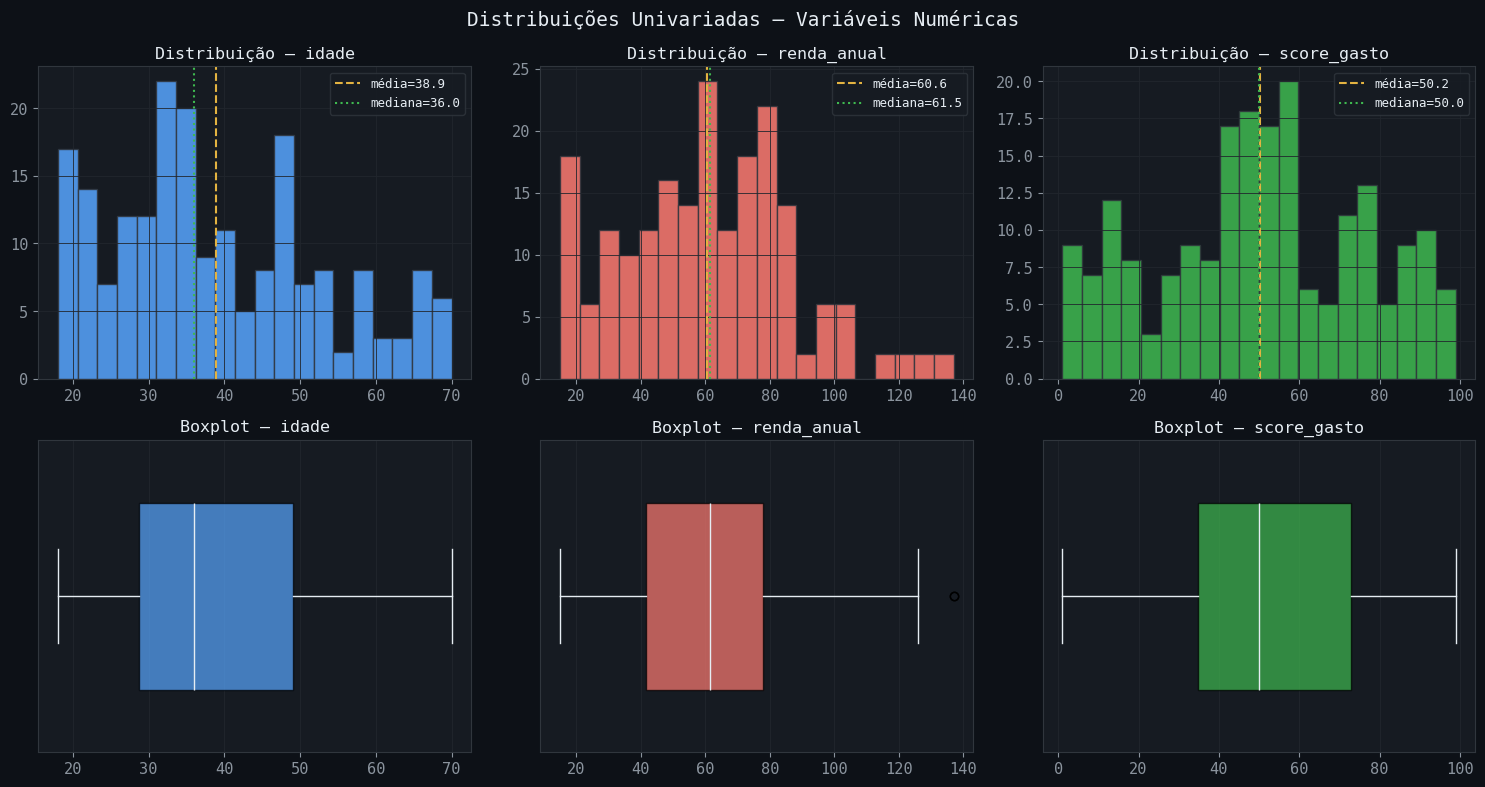

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(NUMERICAS):
    axes[0, i].hist(df[col], bins=20, color=PALETTE[i], edgecolor=CORES["borda"], alpha=0.85)
    axes[0, i].axvline(df[col].mean(), color=CORES["amarelo"], linestyle="--", linewidth=1.5,
                      label=f"média={df[col].mean():.1f}")
    axes[0, i].axvline(df[col].median(), color=CORES["verde"], linestyle=":", linewidth=1.5,
                      label=f"mediana={df[col].median():.1f}")
    axes[0, i].set_title(f"Distribuição — {col}")
    axes[0, i].legend()

    bp = axes[1, i].boxplot(df[col], vert=False, patch_artist=True, widths=0.6)
    bp["boxes"][0].set_facecolor(PALETTE[i])
    bp["boxes"][0].set_alpha(0.7)
    for elem in ["whiskers", "caps", "medians"]:
        for line in bp[elem]:
            line.set_color(CORES["texto"])
    axes[1, i].set_title(f"Boxplot — {col}")
    axes[1, i].set_yticks([])

plt.suptitle("Distribuições Univariadas — Variáveis Numéricas", fontsize=14)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb01_distribuicoes_univariadas.png", dpi=150, bbox_inches="tight")
plt.show()

A variável `score_gasto` apresentou um padrão multimodal sugere a existência de subgrupos distintos de consumidores com comportamentos de gasto diferentes:

- distribuição praticamente simétrica (`skew ≈ -0.05`);
- curtose negativa (`kurtosis ≈ -0.83`), indicando uma distribuição mais achatada que a normal;
- forte concentração de observações na região central, próxima ao valor 50;
- presença de densidades adicionais nas extremidades da distribuição.

A variável `renda_anual` também apresentou indícios de múltiplos agrupamentos:

- distribuição com mais de um pico;
- curtose levemente negativa (`kurtosis ≈ -0.10`);
- presença de um possível outlier próximo de `137 mil`.

A variável `idade` apresentou:

- teve assimetria positiva (`skew ≈ 0.49`);
- concentração expressiva de clientes entre 30 e 35 anos;
- indícios de um segundo agrupamento em faixas etárias mais elevadas.

A distribuição da variável `genero` mostrou leve desbalanceamento:

- aproximadamente `56%` de mulheres;
- aproximadamente `44%` de homens.

### Etapa 5 — Hopkins statistic + Shapiro-Wilk

Como vimos na análise exploratória das variáveis acima, nenhuma das três variáveis apresentam uma distribuição normal e todos sugerem estrutura de subgrupo. Vamos utilizar *Hopkins statistic* para olhar a tendência de clusterização e *Shapiro-Wilk* para testar a normalidade dessas features.

Vamos criar uma escala local só para esses testes.

In [15]:
X_num = df[NUMERICAS].values
X_scaled = StandardScaler().fit_transform(X_num)

In [16]:
def hopkins(X, m_frac=0.1, random_state=42):
    """
    Mede tendência de clusterização.
      H ≈ 0.5 → dados sem estrutura (uniformes)
      H → 1.0 → forte tendência de agrupamento
    """
    rng  = np.random.default_rng(random_state)
    n, d = X.shape
    m    = max(int(m_frac * n), 1)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # w: distância de pontos REAIS ao vizinho mais próximo (exclui si mesmo)
    idx       = rng.choice(n, m, replace=False)
    w_dist, _ = nbrs.kneighbors(X[idx], n_neighbors=2)
    w         = w_dist[:, 1]

    # u: distância de pontos UNIFORMES artificiais ao vizinho real
    U         = rng.uniform(X.min(axis=0), X.max(axis=0), size=(m, d))
    u_dist, _ = nbrs.kneighbors(U, n_neighbors=1)
    u         = u_dist[:, 0]

    return u.sum() / (u.sum() + w.sum())

# Roda múltiplas seeds (Hopkins é estocástico) → média ± desvio
valores_h = [hopkins(X_scaled, random_state=s) for s in range(20)]
h_media, h_std = np.mean(valores_h), np.std(valores_h)

In [17]:
print("═" * 50)
print("HOPKINS STATISTIC (tendência de clusterização)")
print("═" * 50)

print(f"   H = {h_media:.3f} ± {h_std:.3f}   (20 execuções)")
if h_media >= 0.75:
    print("   ✅ Forte tendência de clusterização — segmentar é justificável")
elif h_media >= 0.6:
    print("   ⚠️  Tendência moderada de clusterização")
else:
    print("   ❌ Pouca estrutura — dados próximos de uniformes")

══════════════════════════════════════════════════
HOPKINS STATISTIC (tendência de clusterização)
══════════════════════════════════════════════════
   H = 0.704 ± 0.041   (20 execuções)
   ⚠️  Tendência moderada de clusterização


In [18]:
print("\n" + "═" * 50)
print("SHAPIRO-WILK (H0: distribuição é normal)")
print("═" * 50)

for col in NUMERICAS:
    stat, p = shapiro(df[col])
    veredito = "❌ rejeita normalidade" if p < 0.05 else "✅ não rejeita normalidade"
    print(f"   {col:<14}: W={stat:.4f}  p={p:.4f}  →  {veredito}")


══════════════════════════════════════════════════
SHAPIRO-WILK (H0: distribuição é normal)
══════════════════════════════════════════════════
   idade         : W=0.9516  p=0.0000  →  ❌ rejeita normalidade
   renda_anual   : W=0.9784  p=0.0035  →  ❌ rejeita normalidade
   score_gasto   : W=0.9695  p=0.0002  →  ❌ rejeita normalidade


Foi avaliada a tendência natural de agrupamento dos dados por meio da estatística de Hopkins.

- `Hopkins = 0.704 ± 0.041`

O resultado indica uma tendência moderada de clusterização, situando-se significativamente acima do valor de referência (0.5), associado a distribuições aleatórias sem estrutura de agrupamento. O baixo desvio padrão (`± 0.041`) demonstra estabilidade da métrica entre diferentes execuções,

A normalidade das variáveis foi avaliada utilizando o teste de Shapiro-Wilk. Os resultados indicaram rejeição da hipótese de normalidade para todas as variáveis analisadas:

- `p < 0.05` em todos os casos.

Diante desse cenário, optou-se por priorizar métodos estatísticos não paramétricos nas análises subsequentes:

- Correlação de Spearman como medida principal de associação entre variáveis;
- Teste de Mann-Whitney U para comparação de distribuições entre grupos de gênero.

### Etapa 6 — Correlação (Spearman + Pearson) + heatmap

In [19]:
corr_spearman = df[NUMERICAS].corr(method="spearman")
corr_pearson  = df[NUMERICAS].corr(method="pearson")

print("═" * 80)
print("CORRELAÇÃO PAR A PAR (com p-valor)")
print("═" * 80)
print(f"   {'par':<28}{'Spearman':>12}{'p':>10}{'Pearson':>12}{'p':>10}")
print("   " + "─" * 77)
for i in range(len(NUMERICAS)):
    for j in range(i + 1, len(NUMERICAS)):
        a, b = NUMERICAS[i], NUMERICAS[j]
        rs, ps = spearmanr(df[a], df[b])
        rp, pp = pearsonr(df[a], df[b])
        par = f"{a} × {b}"
        print(f"   {par:<28}{rs:>12.3f}{ps:>10.4f}{rp:>12.3f}{pp:>10.4f}")

════════════════════════════════════════════════════════════════════════════════
CORRELAÇÃO PAR A PAR (com p-valor)
════════════════════════════════════════════════════════════════════════════════
   par                             Spearman         p     Pearson         p
   ─────────────────────────────────────────────────────────────────────────────
   idade × renda_anual                0.020    0.7812      -0.012    0.8617
   idade × score_gasto               -0.345    0.0000      -0.327    0.0000
   renda_anual × score_gasto          0.008    0.9123       0.010    0.8893


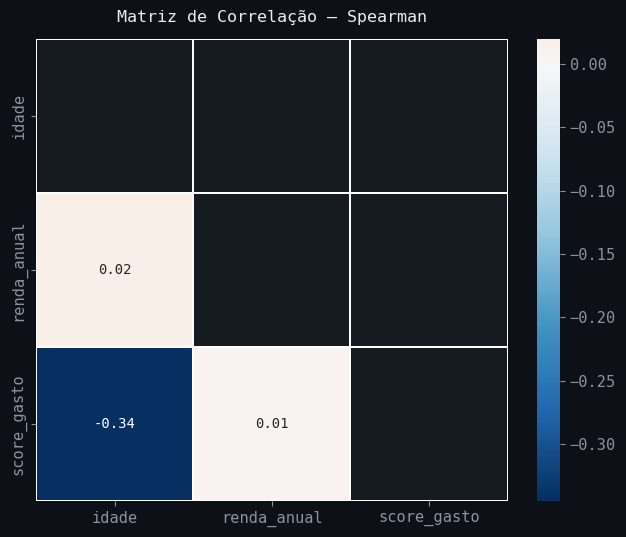

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(
    corr_spearman, mask=mask, annot=True, fmt='.2f',
    cmap="RdBu_r", center=0, linewidths=0.3,
    ax=ax, annot_kws={'size': 10},
    cbar_kws={'shrink': 1},
)

ax.set_title("Matriz de Correlação — Spearman", pad=12)

plt.tight_layout()
plt.grid(False)
plt.savefig(FIG_DIR / 'nb01_correlacao_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

- `renda_anual` × `score_gasto` ≈ 0 (`Spearman 0.008, p=0.91`) — praticamente independência total. Esse é exatamente o achado que sustenta os quatro quadrantes do Mall: renda e gasto variam livremente um do outro, formando os grupos clássicos (renda alta/gasto alto, renda alta/gasto baixo, etc.). Sem correlação = cada eixo separa de forma independente.

- `idade` × `score_gasto` = −0.345 (`p < 0.0001`) — a única relação significativa: clientes mais velhos tendem a gastar menos. Moderada mas real, e Spearman ≈ Pearson (−0.34 vs −0.33), então é relação monotônica linear, sem curva escondida.

- `idade` × `renda_anual` ≈ 0 (`p=0.78`) — sem relação.

### Etapa 7 — Levene (variância) + Mann-Whitney U (diferença por gênero)

In [23]:
grupo_f = df[df["genero"] == "Female"]
grupo_m = df[df["genero"] == "Male"]

print("═" * 60)
print("DIFERENÇA ENTRE GÊNEROS (Female vs Male)")
print("═" * 60)
print("   Shapiro rejeitou normalidade → Mann-Whitney é o teste principal")
print("   (t-test mostrado como comparação)\n")

print(f"   {'variável':<14}{'Levene p':>10}{'M-W U p':>10}{'t-test p':>10}"
      f"{'med F':>8}{'med M':>8}")
print("   " + "─" * 64)

for col in NUMERICAS:
    f_vals = grupo_f[col]
    m_vals = grupo_m[col]

    _, p_lev = levene(f_vals, m_vals)

    _, p_mw = mannwhitneyu(f_vals, m_vals, alternative="two-sided")

    var_igual = p_lev >= 0.05
    _, p_t = ttest_ind(f_vals, m_vals, equal_var=var_igual)

    med_f, med_m = f_vals.median(), m_vals.median()

    print(f"   {col:<14}{p_lev:>10.4f}{p_mw:>10.4f}{p_t:>10.4f}"
          f"{med_f:>8.1f}{med_m:>8.1f}")

════════════════════════════════════════════════════════════
DIFERENÇA ENTRE GÊNEROS (Female vs Male)
════════════════════════════════════════════════════════════
   Shapiro rejeitou normalidade → Mann-Whitney é o teste principal
   (t-test mostrado como comparação)

   variável        Levene p   M-W U p  t-test p   med F   med M
   ────────────────────────────────────────────────────────────────
   idade             0.0373    0.6242    0.4036    35.0    37.0
   renda_anual       0.9229    0.4144    0.4276    60.0    62.5
   score_gasto       0.1275    0.5713    0.4137    50.0    50.0


Interpretação:

- Levene p < 0.05  → variâncias diferentes (t-test usa Welch)
- M-W U  p < 0.05  → distribuição difere entre gêneros
- NÃO mostra diferença forte por gênero → reforça nossa decisão de deixar `genero` fora do KMeans

### Etapa 8 — Scatter renda × score_gasto

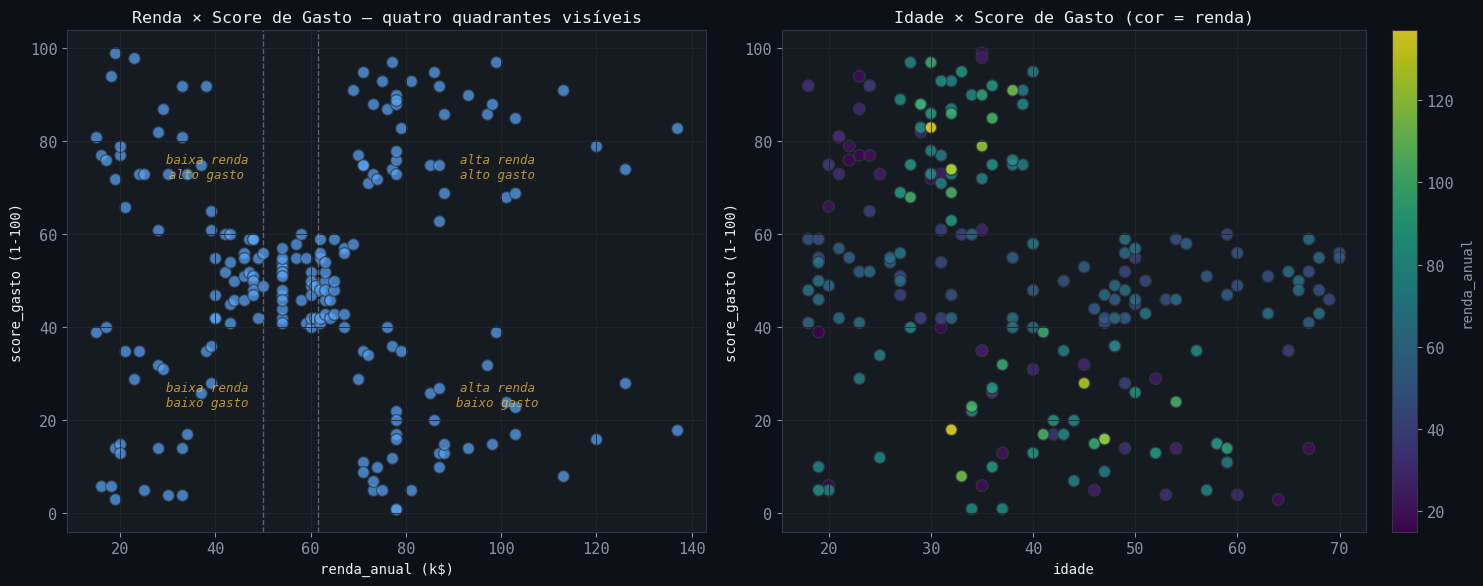

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(
    df["renda_anual"], df["score_gasto"],
    c=PALETTE[0], s=70, alpha=0.7, edgecolor=CORES["borda"]
)
axes[0].axvline(df["renda_anual"].median(), color=CORES["texto2"], linestyle="--", linewidth=1, alpha=0.6)
axes[0].axvline(df["score_gasto"].median(), color=CORES["texto2"], linestyle="--", linewidth=1, alpha=0.6)

axes[0].set_xlabel("renda_anual (k$)")
axes[0].set_ylabel("score_gasto (1-100)")
axes[0].set_title("Renda × Score de Gasto — quatro quadrantes visíveis")

x_med, y_med = df["renda_anual"].median(), df["score_gasto"].median()
x_lo, x_hi   = df["renda_anual"].min(), df["renda_anual"].max()
y_lo, y_hi   = df["score_gasto"].min(), df["score_gasto"].max()
quad = [
    ((x_lo + x_med) / 2, (y_med + y_hi) / 2, "baixa renda\nalto gasto"),
    ((x_med + x_hi) / 2, (y_med + y_hi) / 2, "alta renda\nalto gasto"),
    ((x_lo + x_med) / 2, (y_lo + y_med) / 2, "baixa renda\nbaixo gasto"),
    ((x_med + x_hi) / 2, (y_lo + y_med) / 2, "alta renda\nbaixo gasto"),
]
for x, y, txt in quad:
    axes[0].text(x, y, txt, ha="center", va="center", fontsize=9,
                 color=CORES["amarelo"], alpha=0.8, fontstyle="italic")


sc = axes[1].scatter(
    df["idade"], df["score_gasto"],c=df["renda_anual"], cmap="viridis",
    s=70, alpha=0.8, edgecolor=CORES["borda"]
)
axes[1].set_xlabel("idade")
axes[1].set_ylabel("score_gasto (1-100)")
axes[1].set_title("Idade × Score de Gasto (cor = renda)")

cbar = fig.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label("renda_anual", color=CORES["texto2"])
cbar.ax.tick_params(colors=CORES["texto2"])

plt.tight_layout()
plt.savefig(FIG_DIR / "nb01_scatter_grupos.png", dpi=150, bbox_inches="tight")
plt.show()

### Etapa 9 — Fechamento: Resumo dos achados

`DADOS`
- 200 clientes × 5 colunas → renomeadas p/ snake_case PT-BR
- Zero nulos, zero duplicatas, id_cliente é chave única
- genero: 56% Female / 44% Male

`DISTRIBUIÇÕES (Shapiro-Wilk)`
- idade, renda_anual, score_gasto → TODAS rejeitam normalidade
- Multimodalidade visível → forte indício de subgrupos
- testes não-paramétricos (Spearman, Mann-Whitney)

`TENDÊNCIA DE CLUSTERIZAÇÃO (Hopkins)`
- H = 0.704 ± 0.041 → estrutura MODERADA, segmentação justificável
- Coerente com a geometria: miolo central denso + extremos difusos

`CORRELAÇÕES (Spearman)`
- renda × gasto    ≈ 0.01 (p=0.91) → independentes → 4 quadrantes
- idade × gasto    = -0.34 (p<0.001) → única relação significativa
- idade × renda    ≈ 0.02 (p=0.78) → independentes
- pouca redundância → PCA será p/ visualização, não compressão

`DIFERENÇA POR GÊNERO (Mann-Whitney U)`
- Nenhuma variável difere por gênero (p > 0.41 nas três)
- DECISÃO VALIDADA: genero fica FORA do KMeans, só perfilização

`ESTRUTURA VISUAL (renda × gasto)`
- 5 grupos visíveis: 1 central + 4 extremos nos quadrantes
- candidato natural: k=5 (confirmar via cotovelo + silhouette no NB04)

`PRÓXIMO PASSO → NB02 (limpeza)`
- Descartar id_cliente (sem sinal p/ clustering)
- Aplicar padronizar_colunas() (mesma função do src/data.py)
- Salvar data/processed/dados_limpos.parquet